# Time series generation through Markov switching autoregression

In signal processing, any stationary signal can be regarded as the output of a linear time-invariant (LTI) system excited by white noise. However, real-world time series often exhibit **regime changes**: the mean, variance, or local autocorrelation structure may shift across different periods. Examples include low-/high-volatility phases in financial data, or segments with different oscillation strengths in physical signals.

The **Markov Switching Autoregression (MSAR)** model extends the white-noise excitation framework by introducing a latent discrete state $S_t \in \{0, 1, \ldots, K-1\}$ that follows a first-order Markov chain. Conditional on the current regime, the output follows a local AR dynamics driven by Gaussian innovations.

Compared with the ARIMA, Wiener-filter, and Kalman-filter simulators in S2Generator, the MSAR simulator is particularly suitable for **piecewise-stationary** or **mixture-distributed** time series whose global statistics cannot be captured by a single ARMA model.

This notebook introduces the method in the following order:

1. Elaboration of the basic mathematical principles.
2. Construction and fitting of an MSAR model from input data.
3. Generation of new sequences by simulating regime paths and white-noise excitations.
4. Visualization and statistical comparison with the input sequence.
5. Usage of the encapsulated `MarkovSwitchingSimulator` in S2Generator.

## Markov switching autoregression model

Let $y_t$ denote the observed time series and $S_t$ the unobserved regime indicator at time $t$. A Markov switching AR($p$) model with $K$ regimes can be written as:
$$
y_t = a_{S_t} + \sum_{j=1}^{p} \varphi_{j,S_t}
\Big(y_{t-j} - a_{S_{t-j}}\Big) + \varepsilon_t, \quad
\varepsilon_t \sim \mathcal{N}(0, \sigma_{S_t}^2). \quad (1)
$$

The latent regime evolves as a first-order Markov chain:
$$
P(S_t = j \mid S_{t-1} = i) = P_{ij}, \quad \sum_{j=0}^{K-1} P_{ij} = 1. \quad (2)
$$

Thus the overall generating mechanism contains **two random excitations**:

1. **Discrete Markov switching**: determines which local linear system is active at each time step;
2. **Continuous Gaussian innovation** $\varepsilon_t$: drives the autoregressive recursion within each regime.

### White-noise-to-signal viewpoint

Unlike a single fixed AR filter, the MSAR model can be interpreted as a **switching linear dynamical system**:
$$
\text{Markov chain } S_t \;\Longrightarrow\; \text{regime-specific AR parameters}
\;\Longrightarrow\; y_t \leftarrow \varepsilon_t.
$$

When $K=1$, the model reduces to a standard AR process. When $K>1$, the marginal distribution of $y_t$ becomes a **mixture of Gaussians**, which provides greater flexibility for fitting time series with changing statistical characteristics.

### Estimation and simulation

Model parameters—including intercepts $a_k$, AR coefficients $\varphi_{j,k}$, variances $\sigma_k^2$, and transition probabilities $P_{ij}$—are estimated by maximum likelihood via the **Hamilton filter** (and optionally the Kim smoother) implemented in `statsmodels`.

To generate a new sample path after fitting:

1. Draw an initial regime from the stationary distribution;
2. For each time step, sample the next regime from the transition matrix;
3. Draw $\varepsilon_t \sim \mathcal{N}(0, \sigma_{S_t}^2)$;
4. Update $y_t$ using equation (1).

The `MarkovSwitchingSimulator` class in S2Generator wraps this entire pipeline behind the same `fit` / `transform` interface used by the other simulators.

Below we import the required libraries and construct a synthetic two-regime series for demonstration.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

from s2generator.simulator import MarkovSwitchingSimulator
from s2generator.utils import plot_simulator_statistics, plot_univariate_time_series

## Step 1: Generate a synthetic regime-switching series

We first synthesize a two-regime AR(1) process. Regime 0 is a low-volatility mean-reverting dynamics, while regime 1 is a high-volatility persistent dynamics. The regime switches according to a Markov chain.

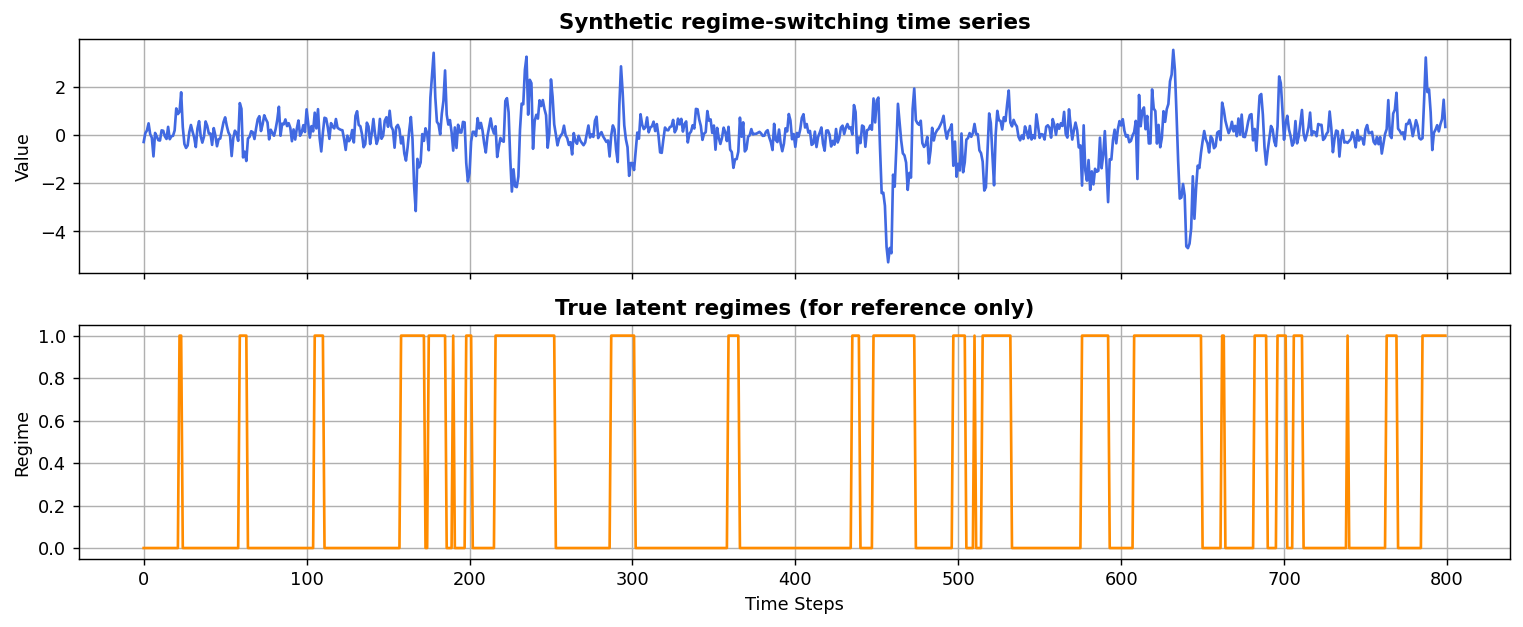

In [2]:
def generate_regime_switching_ar1(
    seq_length: int = 800,
    transition: np.ndarray = None,
    random_state: int = 0,
) -> tuple:
    """Generate a simple two-regime AR(1) process for demonstration."""
    rng = np.random.RandomState(random_state)

    if transition is None:
        # transition[j, i] = P(S_t = j | S_{t-1} = i)
        transition = np.array([[0.95, 0.10], [0.05, 0.90]])

    # Regime-specific parameters: intercept, AR(1) coefficient, innovation std
    const = np.array([0.10, -0.10])
    ar1 = np.array([0.35, 0.85])
    sigma = np.array([0.35, 1.10])

    y = np.zeros(seq_length)
    regimes = np.zeros(seq_length, dtype=int)
    current_regime = rng.choice(2, p=[0.5, 0.5])
    y[0] = const[current_regime] + rng.normal(scale=sigma[current_regime])
    regimes[0] = current_regime

    for t in range(1, seq_length):
        current_regime = rng.choice(2, p=transition[:, current_regime])
        innovation = rng.normal(scale=sigma[current_regime])
        y[t] = (
            const[current_regime]
            + ar1[current_regime] * (y[t - 1] - const[current_regime])
            + innovation
        )
        regimes[t] = current_regime

    return y, regimes


seq_length = 800
time_series, true_regimes = generate_regime_switching_ar1(
    seq_length=seq_length, random_state=42
)

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True, dpi=128)
ax[0].plot(time_series, color="royalblue")
ax[0].set_title("Synthetic regime-switching time series", fontweight="bold")
ax[0].set_ylabel("Value")
ax[0].grid(True)
ax[1].plot(true_regimes, color="darkorange")
ax[1].set_title("True latent regimes (for reference only)", fontweight="bold")
ax[1].set_xlabel("Time Steps")
ax[1].set_ylabel("Regime")
ax[1].grid(True)
plt.tight_layout()

## Step 2: Fit the MSAR model manually with statsmodels

Before using the encapsulated simulator, we fit a `MarkovAutoregression` model directly to inspect the estimated parameters.

In [3]:
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression

k_regimes = 2
order = 1

msar_model = MarkovAutoregression(
    endog=time_series,
    k_regimes=k_regimes,
    order=order,
    trend="c",
    switching_ar=True,
    switching_trend=True,
    switching_variance=True,
)
msar_result = msar_model.fit(disp=False, maxiter=200)

print(msar_result.summary())
print("\nEstimated transition matrix (P[S_t=j | S_{t-1}=i]):")
print(msar_result.regime_transition[:, :, 0])

                         Markov Switching Model Results                         
Dep. Variable:                        y   No. Observations:                  799
Model:             MarkovAutoregression   Log Likelihood                -683.307
Date:                  Sun, 21 Jun 2026   AIC                           1382.615
Time:                          12:06:55   BIC                           1420.082
Sample:                               0   HQIC                          1397.009
                                  - 799                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1088      0.027      4.096      0.000       0.057       0.161
sigma2         0.1371      0.011    

## Step 3: Inspect smoothed regime probabilities

After fitting, the Kim smoother provides the posterior probability of each regime at every time step. This helps verify whether the model has identified the low-/high-volatility segments in the input series.

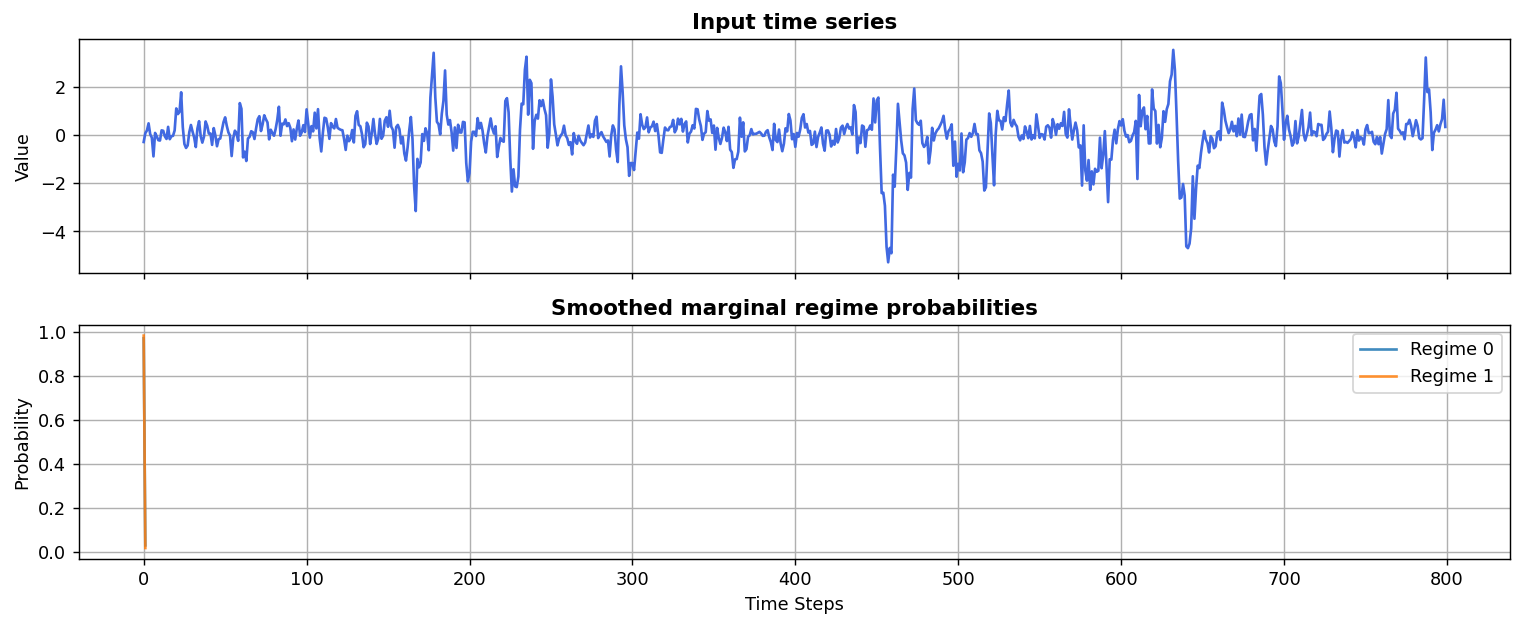

In [8]:
smoothed_probs = msar_result.smoothed_marginal_probabilities

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True, dpi=128)
ax[0].plot(time_series, color="royalblue")
ax[0].set_title("Input time series", fontweight="bold")
ax[0].set_ylabel("Value")
ax[0].grid(True)

for regime in range(k_regimes):
    ax[1].plot(
        smoothed_probs[regime],
        label=f"Regime {regime}",
        alpha=0.85,
    )

ax[1].set_title("Smoothed marginal regime probabilities", fontweight="bold")
ax[1].set_xlabel("Time Steps")
ax[1].set_ylabel("Probability")
ax[1].legend()
ax[1].grid(True)
plt.tight_layout()

## Step 4: Generate a new sequence from the fitted MSAR dynamics

We simulate a new path by drawing both a Markov regime sequence and regime-specific Gaussian innovations, then propagating the switching AR recursion forward in time.

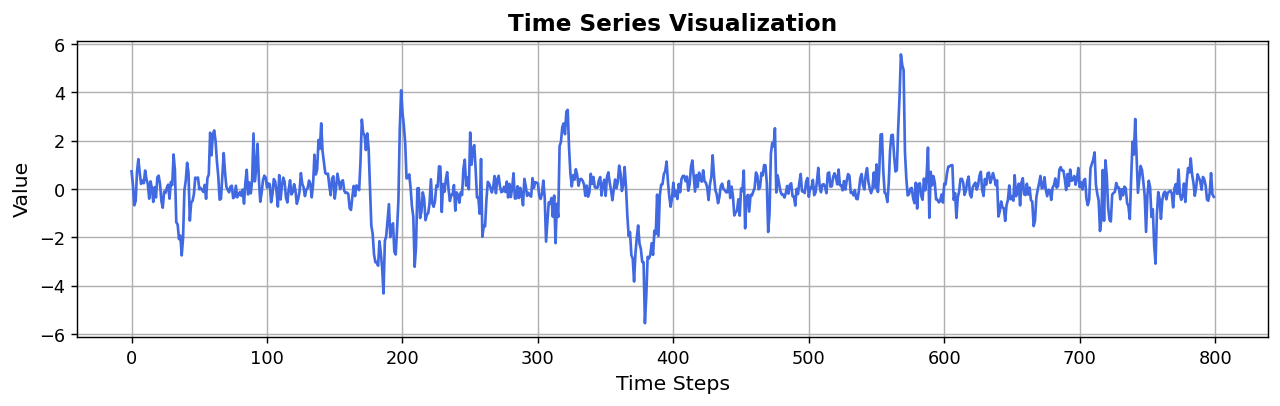

In [ ]:
def simulate_msar_path(result, seq_length, random_state=7):
    """Simulate one MSAR sample path from a fitted statsmodels result object."""
    rng = np.random.RandomState(random_state)
    k = result.k_regimes
    p = result.order
    model = result.model
    params = result.params

    const = np.zeros(k)
    ar = np.zeros((k, p))
    for regime in range(k):
        const[regime] = params[model.parameters[regime, "exog"]][0]
        ar[regime, :] = params[model.parameters[regime, "autoregressive"]]

    variance = params[model.parameters["variance"]]
    variance = np.atleast_1d(variance)
    if variance.size == 1:
        variance = np.repeat(variance[0], k)

    transition = result.regime_transition[:, :, 0]
    current_regime = rng.choice(k, p=result.initial_probabilities)
    y_hist = [const[current_regime]] * p
    s_hist = [current_regime] * p
    simulated = np.zeros(seq_length)

    for t in range(seq_length):
        current_regime = rng.choice(k, p=transition[:, s_hist[-1]])
        innovation = rng.normal(scale=np.sqrt(variance[current_regime]))
        value = const[current_regime]
        for lag in range(1, p + 1):
            value += ar[current_regime, lag - 1] * (y_hist[-lag] - const[s_hist[-lag]])
        value += innovation
        simulated[t] = value
        y_hist.append(value)
        s_hist.append(current_regime)

    return simulated


generated_series = simulate_msar_path(
    msar_result, seq_length=seq_length, random_state=7
)
fig = plot_univariate_time_series(generated_series, dpi=128)

## Step 5: Statistical comparison

We compare the original and generated sequences in the time domain, distribution, autocorrelation, power spectral density, and residual diagnostics.

Text(0.5, 1.01, 'Manual MSAR pipeline: original vs generated')

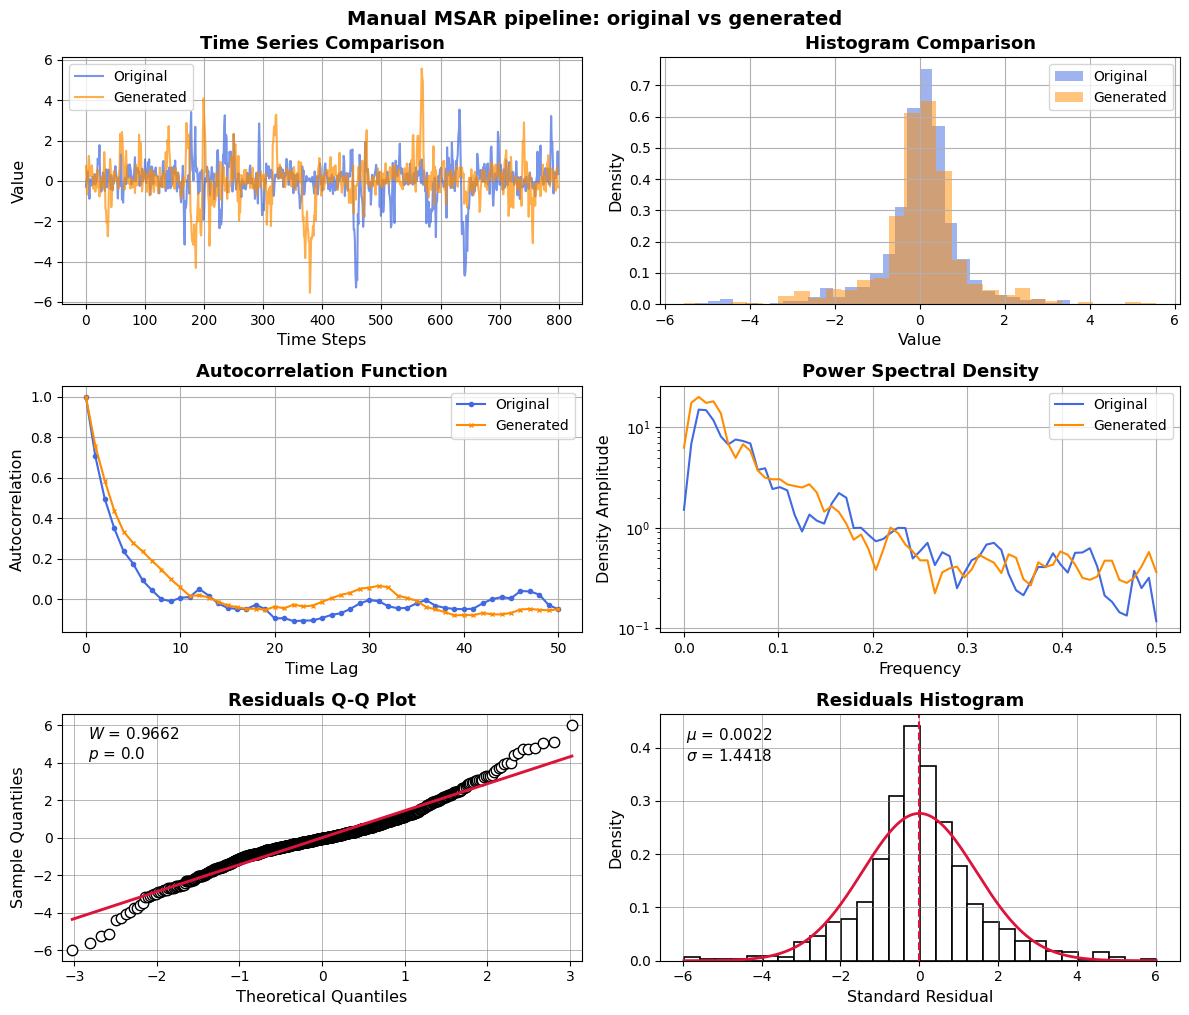

In [6]:
fig = plot_simulator_statistics(
    original_series=time_series,
    generated_series=generated_series,
    residuals=generated_series - time_series,
)
fig.suptitle(
    "Manual MSAR pipeline: original vs generated",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)

The generated sequence preserves key second-order characteristics of the input while reflecting the mixture structure induced by regime switching. Because MSAR captures **local** dynamics rather than a single global ARMA model, it is often more appropriate for time series with changing variance or local persistence.

---

## Using `MarkovSwitchingSimulator` in S2Generator

The entire pipeline above is encapsulated in the `MarkovSwitchingSimulator` class. Its API is consistent with `ARIMASimulator`, `WienerFilterSimulator`, and `KalmanFilterSimulator`: call `fit` on the input series, then `transform` to generate new samples.

In [9]:
simulator = MarkovSwitchingSimulator(
    max_k_regimes=2,
    max_order=2,
    switching_variance=True,
    revin=True,
    random_state=42,
    not_white_alarm=False,
)

# Fit with automatic (K, p) selection via BIC
simulator.fit(time_series, select_order=True)

print("Fit summary")
print(f"  k_regimes : {simulator.k_regimes}")
print(f"  order     : {simulator.order}")
print(f"  BIC       : {simulator.model.bic:.4f}")
print(f"  params    : {simulator.params}")
print("\nTransition matrix:")
print(simulator.regime_transition[:, :, 0])

Fit summary
  k_regimes : 2
  order     : 1
  BIC       : 1483.0604
  params    : [0.95451619 0.10438313 0.08538416 0.14022145 0.1483117  1.21584304
 0.35594204 0.79297849]

Transition matrix:
[[0.95451619 0.10438313]
 [0.04548381 0.89561687]]


Generated batch shape: (5, 800)


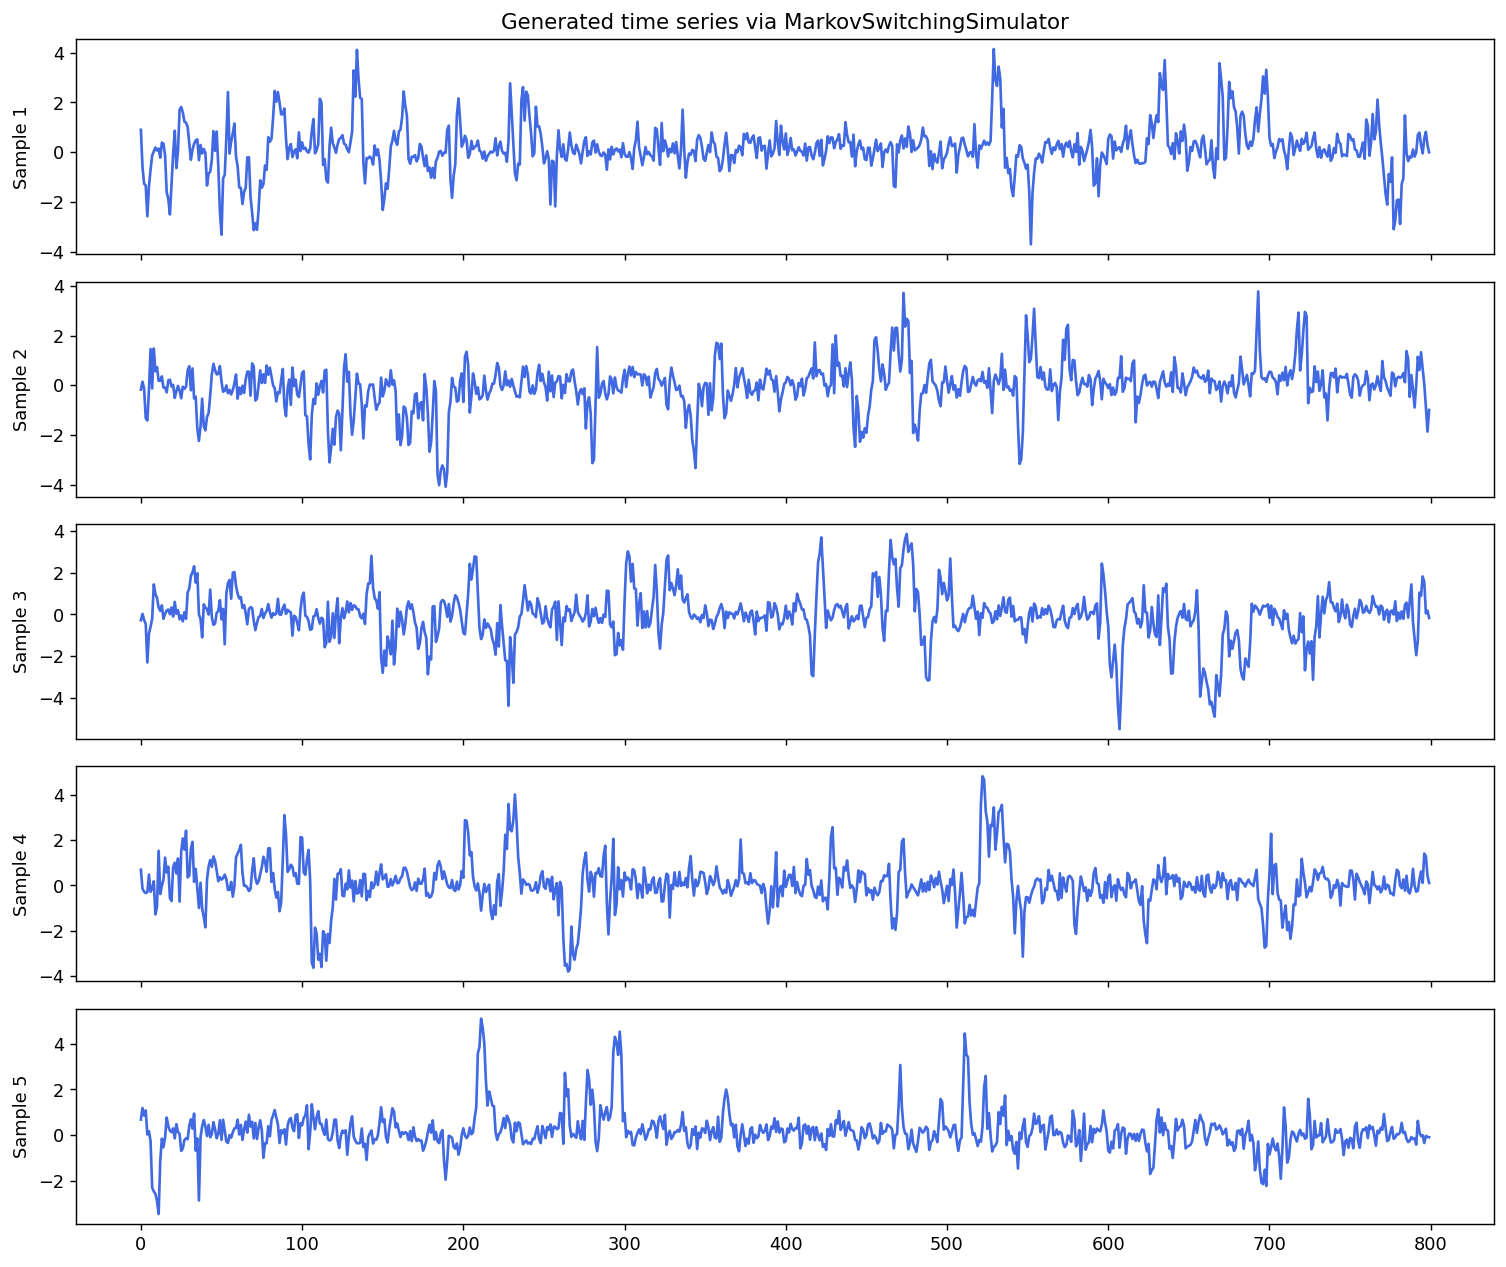

In [10]:
generated_batch = simulator.transform(
    num_samples=5,
    seq_length=seq_length,
    random_state=128,
)
print("Generated batch shape:", generated_batch.shape)

fig, ax = plt.subplots(5, 1, figsize=(12, 10), sharex=True, dpi=128)
for i, series in enumerate(generated_batch):
    ax[i].plot(series, color="royalblue")
    ax[i].set_ylabel(f"Sample {i + 1}")
ax[0].set_title("Generated time series via MarkovSwitchingSimulator")
plt.tight_layout()

Text(0.5, 1.01, 'MarkovSwitchingSimulator: original vs generated')

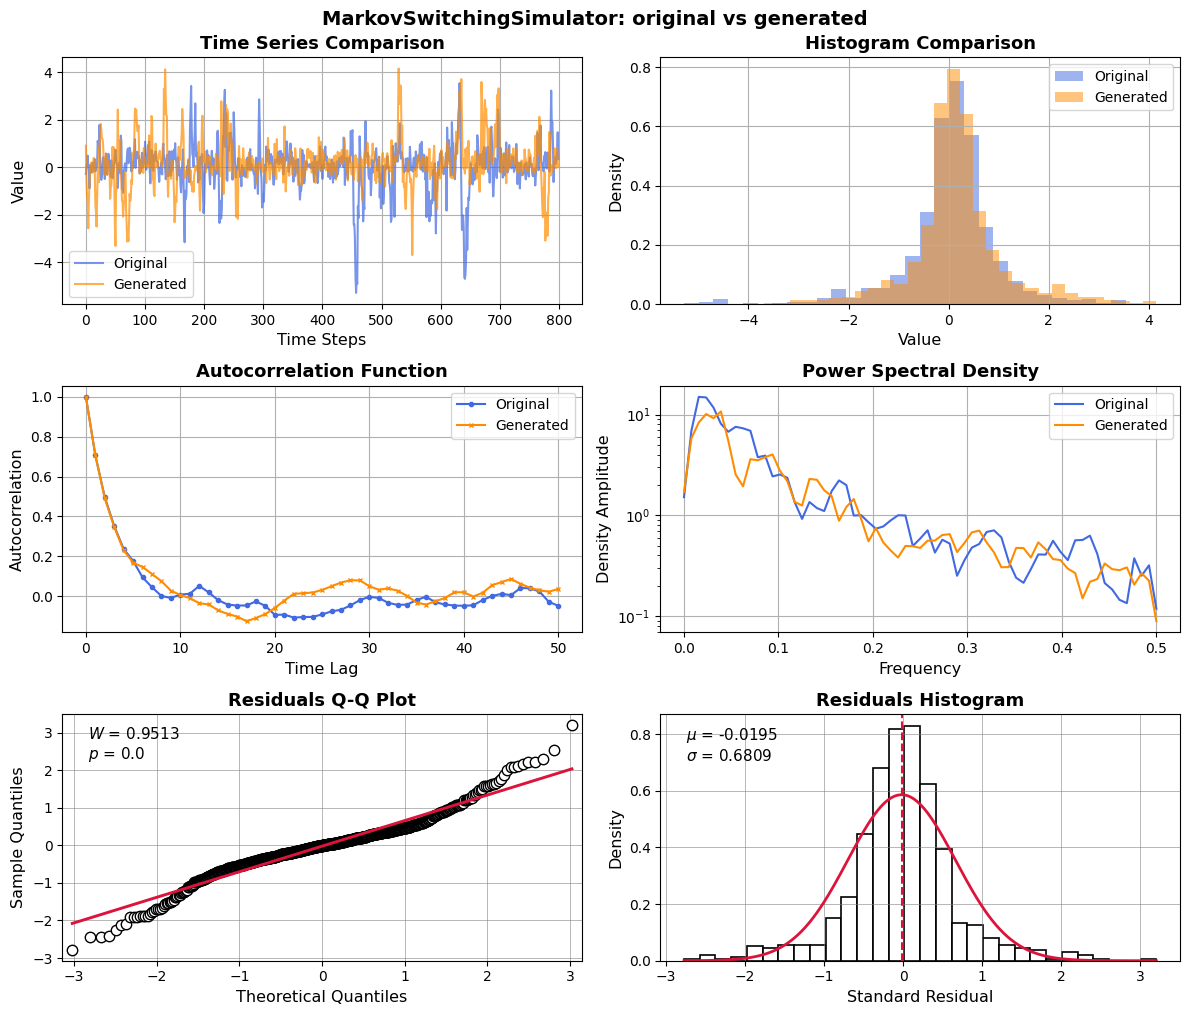

In [11]:
fig = plot_simulator_statistics(
    original_series=time_series,
    generated_series=generated_batch[0],
    residuals=simulator.residuals,
)
fig.suptitle(
    "MarkovSwitchingSimulator: original vs generated",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)

### Supplementary demo: real spectrum data

The following cell applies the same workflow to a real spectrum sequence, similar to the Wiener-filter and Kalman-filter notebooks.

Text(0.5, 1.01, 'MarkovSwitchingSimulator: spectrum data test')

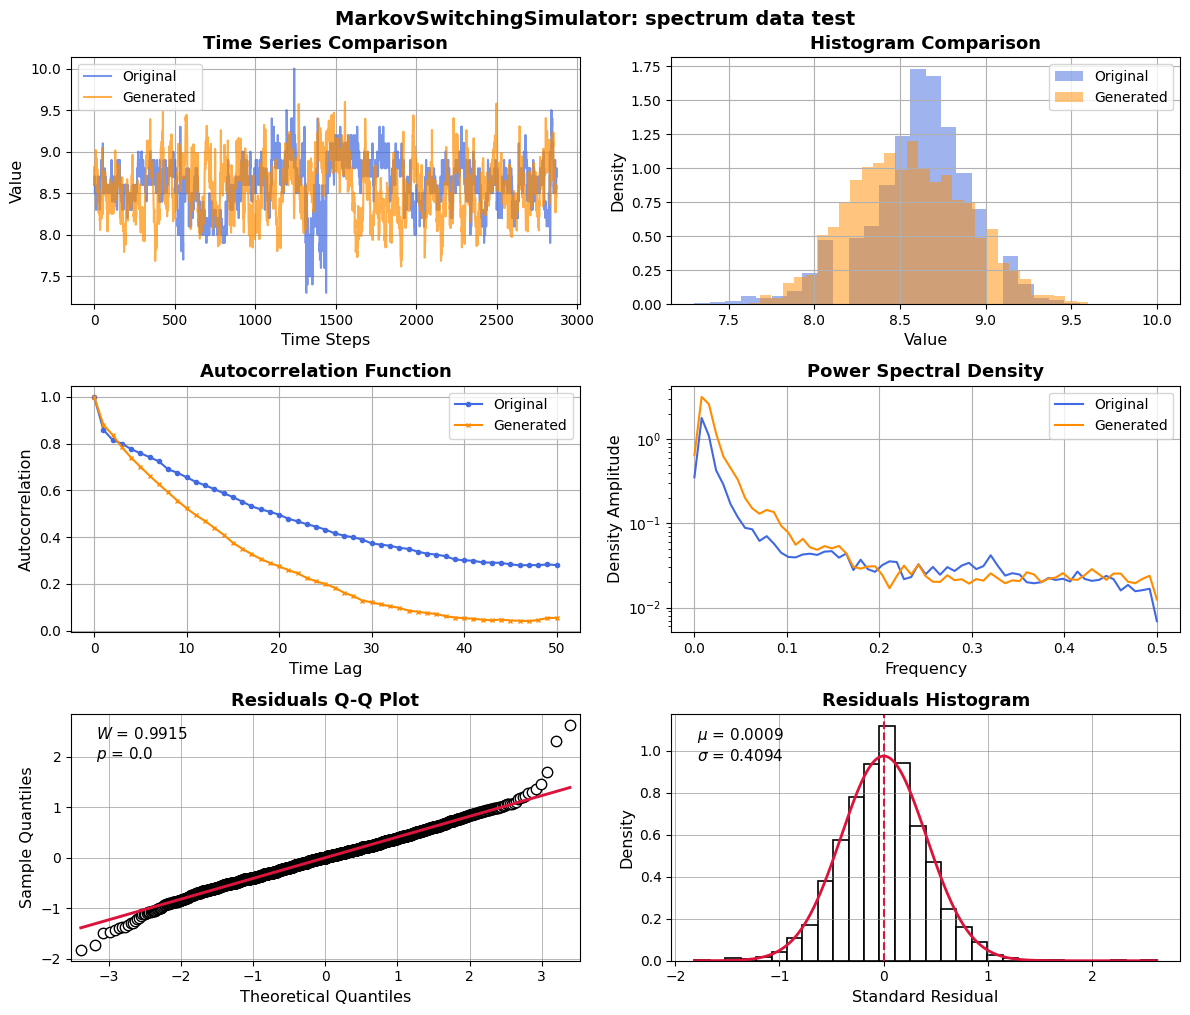

In [12]:
spectrum_series = np.load("..\\docs\\source\\_static\\spectrum.npy")

spectrum_simulator = MarkovSwitchingSimulator(
    max_k_regimes=2,
    max_order=2,
    switching_variance=False,
    revin=True,
    random_state=42,
    not_white_alarm=False,
)
spectrum_simulator.fit(spectrum_series, select_order=True)
spectrum_generated = spectrum_simulator.transform(
    num_samples=1, seq_length=len(spectrum_series), random_state=7
)[0]

fig = plot_simulator_statistics(
    original_series=spectrum_series,
    generated_series=spectrum_generated,
    residuals=spectrum_simulator.residuals,
)
fig.suptitle(
    "MarkovSwitchingSimulator: spectrum data test",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)